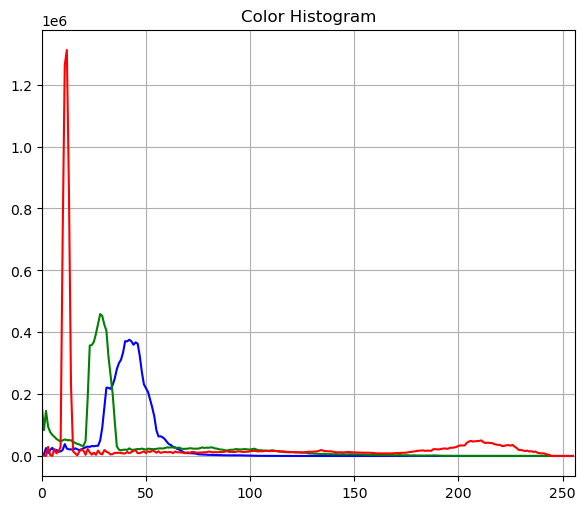

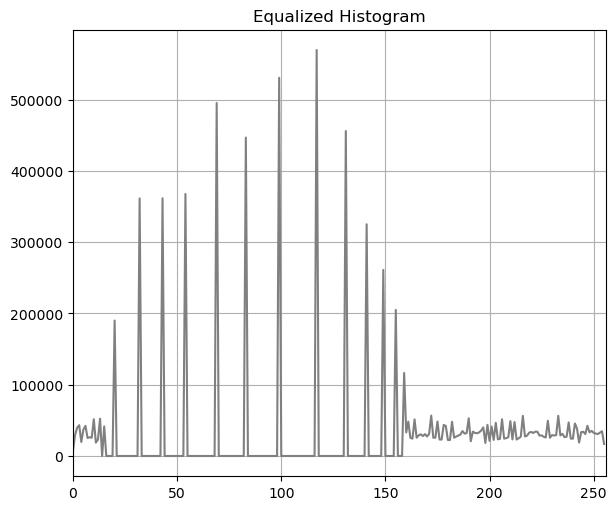

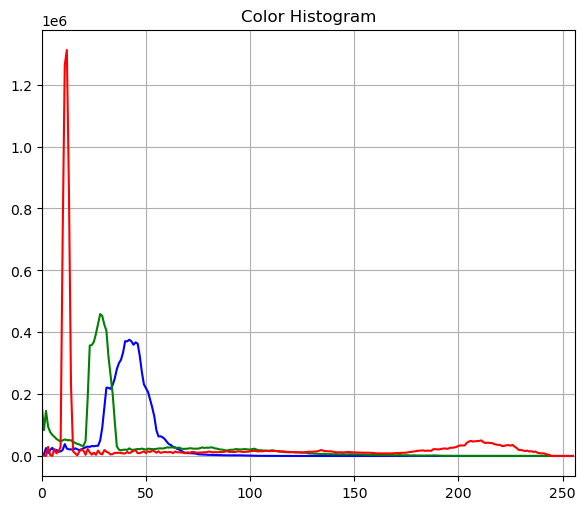

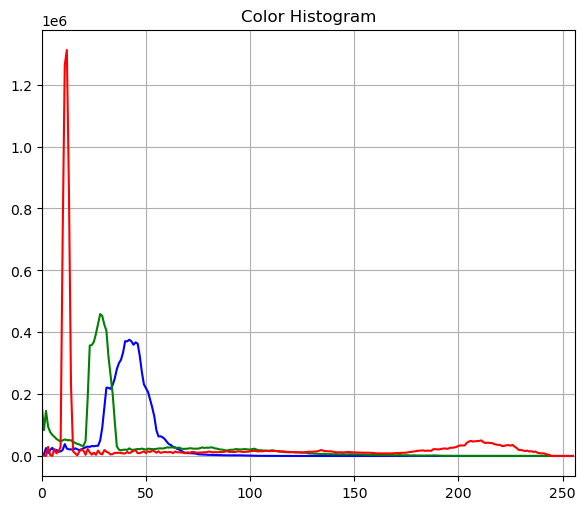

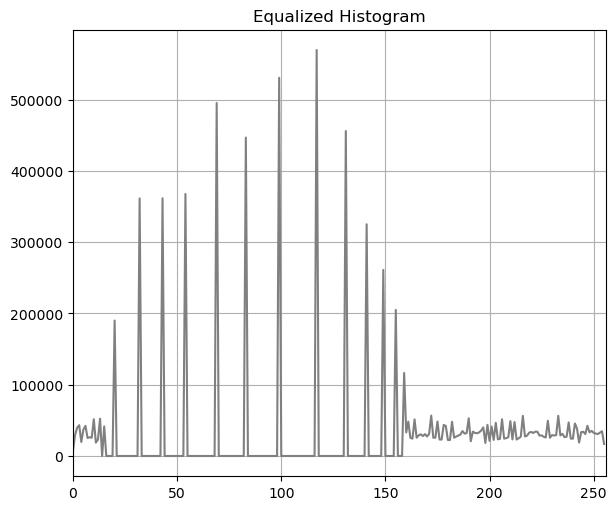

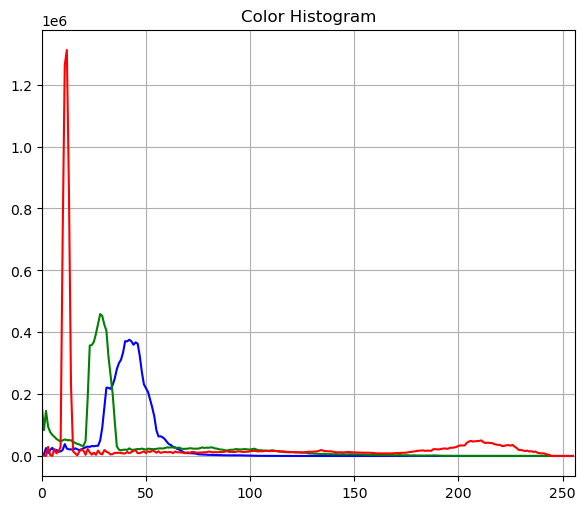

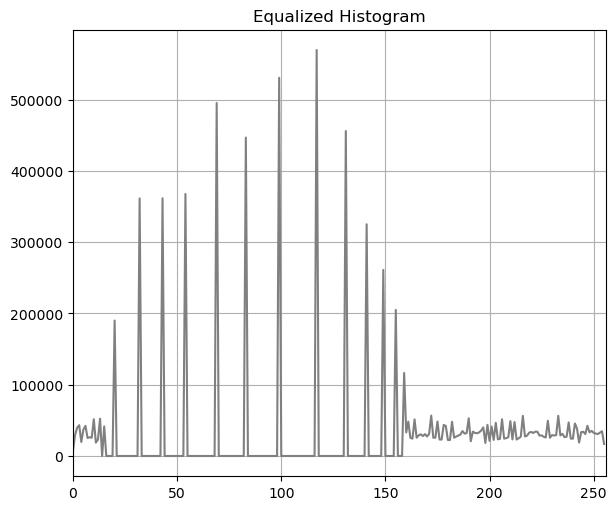

In [2]:
import cv2
import numpy as np
from tkinter import *
from tkinter import filedialog, messagebox
from PIL import Image, ImageTk
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# Global variables
img = None
original_img = None

def load_image():
    global img, original_img
    path = filedialog.askopenfilename(filetypes=[("Image Files", "*.jpg *.png *.jpeg *.bmp")])
    if path:
        original_img = cv2.imread(path)
        if original_img is not None:
            img = original_img.copy()
            show_image(img)
        else:
            messagebox.showerror("Error", "Failed to load image.")
    else:
        messagebox.showwarning("Warning", "No image selected.")
# Show image in Tkinter label
def show_image(image):
    global image_label, canvas, plot_frame

    # Clear previous plot or image
    for widget in plot_frame.winfo_children():
        widget.destroy()

    if image is not None:
        img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)
        img_pil.thumbnail((400, 400))
        img_tk = ImageTk.PhotoImage(img_pil)
        image_label.config(image=img_tk)
        image_label.image = img_tk
    else:
        image_label.config(text="No Image Loaded", image=None)

# Reset image to original
def reset_image():
    global img, original_img
    if original_img is not None:
        img = original_img.copy()
        show_image(img)
    else:
        messagebox.showinfo("Info", "No image loaded.")

# Show color channels
def show_channel(channel_type):
    global img, original_img
    if original_img is not None:
        b, g, r = cv2.split(original_img)
        zeros = np.zeros_like(b)

        if channel_type == "red":
            channel_img = cv2.merge([zeros, zeros, r])
        elif channel_type == "green":
            channel_img = cv2.merge([zeros, g, zeros])
        elif channel_type == "blue":
            channel_img = cv2.merge([b, zeros, zeros])
        elif channel_type == "grayscale":
            gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
            channel_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        else:
            channel_img = original_img

        show_image(channel_img)
    else:
        messagebox.showwarning("Warning", "Please load an image first.")

# Apply brightness
def adjust_brightness():
    global img, original_img
    if original_img is not None:
        brighter = cv2.convertScaleAbs(original_img, alpha=1.0, beta=50)
        show_image(brighter)
    else:
        messagebox.showwarning("Warning", "Please load an image first.")

# Apply Gaussian blur
def apply_gaussian():
    global img, original_img
    if original_img is not None:
        blurred = cv2.GaussianBlur(original_img, (15, 15), 0)
        show_image(blurred)
    else:
        messagebox.showwarning("Warning", "Please load an image first.")

# Apply negative filter
def apply_negative():
    global img, original_img
    if original_img is not None:
        negative = cv2.bitwise_not(original_img)
        show_image(negative)
    else:
        messagebox.showwarning("Warning", "Please load an image first.")

# Apply Sobel edge detection
def apply_sobel():
    global img, original_img
    if original_img is not None:
        gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
        sobel = cv2.magnitude(sobelx, sobely)
        sobel = np.uint8(np.clip(sobel, 0, 255))
        sobel_bgr = cv2.cvtColor(sobel, cv2.COLOR_GRAY2BGR)
        show_image(sobel_bgr)
    else:
        messagebox.showwarning("Warning", "Please load an image first.")

# Show histogram of the image
def show_histogram():
    global original_img
    if original_img is not None:
        color = ('b', 'g', 'r')
        fig, ax = plt.subplots(figsize=(4, 3))
        for i, col in enumerate(color):
            histr = cv2.calcHist([original_img], [i], None, [256], [0, 256])
            ax.plot(histr, color=col)
            ax.set_xlim([0, 256])
        ax.set_title("Color Histogram")
        ax.grid(True)

        # Embed plot in Tkinter
        for widget in plot_frame.winfo_children():
            widget.destroy()
        canvas = FigureCanvasTkAgg(fig, master=plot_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(side=TOP, fill=BOTH, expand=1)
    else:
        messagebox.showwarning("Warning", "Please load an image first.")

# Apply histogram equalization
def apply_equalization():
    global img, original_img
    if original_img is not None:
        gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
        equalized = cv2.equalizeHist(gray)
        equalized_bgr = cv2.cvtColor(equalized, cv2.COLOR_GRAY2BGR)
        img = equalized_bgr
        show_image(img)
        # Show histogram after equalization
        fig, ax = plt.subplots(figsize=(4, 3))
        histr = cv2.calcHist([equalized], [0], None, [256], [0, 256])
        ax.plot(histr, color='gray')
        ax.set_xlim([0, 256])
        ax.set_title("Equalized Histogram")
        ax.grid(True)

        # Embed plot in Tkinter
        for widget in plot_frame.winfo_children():
            widget.destroy()
        canvas = FigureCanvasTkAgg(fig, master=plot_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(side=TOP, fill=BOTH, expand=1)
    else:
        messagebox.showwarning("Warning", "Please load an image first.")


# Create main window
window = Tk()
window.title("Image Processing App - Dark Mode")
window.geometry("1100x700")
window.configure(bg="#1e1e1e")

# Button Frame
button_frame = Frame(window, bg="#2d2d2d", pady=10)
button_frame.pack(fill=X, padx=10, pady=5)

btn_style = {
    "font": ("Helvetica", 10, "bold"),
    "bg": "#0d47a1",
    "fg": "white",
    "relief": "flat",
    "bd": 0,
    "width": 20,
    "height": 2,
    "activebackground": "#1565c0"
}

buttons = [
    ("Open Image", load_image),
    ("Reset Image", reset_image),
    ("Show Histogram", show_histogram),
    ("Histogram Equalization", apply_equalization),
]

columns = 4
for idx, (text, command) in enumerate(buttons):
    row = idx // columns
    col = idx % columns
    Button(button_frame, text=text, command=command, **btn_style).grid(
        row=row, column=col, padx=8, pady=5, sticky="ew"
    )

# Edit Image Dropdown Button
edit_menu = Menubutton(button_frame, text="Edit Image ▼", font=("Helvetica", 10, "bold"),
                       bg="#e53935", fg="white", relief="flat", bd=0, width=20, height=2)
edit_menu.grid(row=0, column=columns, padx=8, pady=5, sticky="ew")

edit_dropdown = Menu(edit_menu, tearoff=0, bg="#2d2d2d", fg="white", font=("Helvetica", 9))
edit_dropdown.add_command(label="Red Channel", command=lambda: show_channel("red"))
edit_dropdown.add_command(label="Green Channel", command=lambda: show_channel("green"))
edit_dropdown.add_command(label="Blue Channel", command=lambda: show_channel("blue"))
edit_dropdown.add_command(label="Grayscale", command=lambda: show_channel("grayscale"))
edit_menu["menu"] = edit_dropdown

# Filter Dropdown Button
filter_menu = Menubutton(button_frame, text="Filter ▼", font=("Helvetica", 10, "bold"),
                         bg="#5e35b1", fg="white", relief="flat", bd=0, width=20, height=2)
filter_menu.grid(row=0, column=columns + 1, padx=8, pady=5, sticky="ew")

filter_dropdown = Menu(filter_menu, tearoff=0, bg="#2d2d2d", fg="white", font=("Helvetica", 9))
filter_dropdown.add_command(label="Gaussian Blur", command=apply_gaussian)
filter_dropdown.add_command(label="Brightness +50", command=adjust_brightness)
filter_dropdown.add_command(label="Negative", command=apply_negative)
filter_dropdown.add_command(label="Sobel Edge Detection", command=apply_sobel)
filter_menu["menu"] = filter_dropdown

for i in range(columns + 2):  # Include Edit and Filter buttons
    button_frame.grid_columnconfigure(i, weight=1)

# Image and Plot Area
main_display = Frame(window, bg="#1e1e1e")
main_display.pack(pady=20, padx=20, fill=BOTH, expand=True)

image_label = Label(main_display, bg="#2a2a2a", fg="white", text="No Image Loaded", font=("Arial", 14), width=40, height=20)
image_label.pack(side=LEFT, padx=10, fill=BOTH, expand=True)

plot_frame = Frame(main_display, bg="#2a2a2a", width=400)
plot_frame.pack_propagate(False)
plot_frame.pack(side=RIGHT, padx=10, fill=BOTH, expand=True)

# Run the app
window.mainloop()